## About Dataset

#### Context
- Predict which e-commerce customers are likely to churn, so the business can target retention offers before they leave. [Kaggle: E Commerce Dataset]

#### Content
Each row represents one customer (`CustomerID`), each column an attribute of that customer's account, engagement, and order history. The dataset includes:

- Whether the customer churned – the column is called `Churn`
- Account/engagement info – tenure on the platform, preferred login device, hours spent on the app, number of devices registered, city tier, distance from warehouse to home
- Order history – preferred order category, preferred payment mode, number of addresses, coupons used, order count, days since last order, order amount hike from last year, cashback amount
- Customer service signal – satisfaction score, whether they raised a complaint
- Demographics – gender, marital status

## Exploration & Data loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../data/raw/E Commerce Dataset.xlsx', sheet_name='E Comm')
df.shape

(5630, 20)

In [3]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [5]:
# NOTE: CustomerID is still in df here, and it's unique per row, so this will
# always read 0 — it hides the real duplicate problem. Check duplicates on the
# feature columns instead (i.e. excluding the ID), which is what actually goes
# into the model:
print("duplicated() with CustomerID still present:", df.duplicated().sum())
print("duplicated() excluding CustomerID:", df.drop(columns=["CustomerID"]).duplicated().sum())

duplicated() with CustomerID still present: 0
duplicated() excluding CustomerID: 556


In [6]:
df.nunique()

CustomerID                     5630
Churn                             2
Tenure                           36
PreferredLoginDevice              3
CityTier                          3
WarehouseToHome                  34
PreferredPaymentMode              7
Gender                            2
HourSpendOnApp                    6
NumberOfDeviceRegistered          6
PreferedOrderCat                  6
SatisfactionScore                 5
MaritalStatus                     3
NumberOfAddress                  15
Complain                          2
OrderAmountHikeFromlastYear      16
CouponUsed                       17
OrderCount                       16
DaySinceLastOrder                22
CashbackAmount                 2586
dtype: int64

In [7]:
pd.set_option('display.max_columns', None)  # Show all columns in the DataFrame
pd.set_option('display.max_rows', None)     # Show all rows in the DataFrame

In [8]:
df.select_dtypes(exclude=np.number).columns

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')

In [9]:
df.describe(include='O').style.background_gradient(axis=None, cmap = "Blues", vmin = 0, vmax = 9000)

,PreferredLoginDevice,PreferredPaymentMode,Gender,PreferedOrderCat,MaritalStatus
count,5630,5630,5630,5630,5630
unique,3,7,2,6,3
top,Mobile Phone,Debit Card,Male,Laptop & Accessory,Married
freq,2765,2314,3384,2050,2986


In [10]:
# Show the unique values on each column.
for col in df.columns:
    if df[col].dtype == object:
        print(str(col) + ' : ' + str(df[col].unique()))
        print(df[col].value_counts())
        print("________________________________________________________________________________")


PreferredLoginDevice : ['Mobile Phone' 'Phone' 'Computer']
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
________________________________________________________________________________
PreferredPaymentMode : ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
________________________________________________________________________________
Gender : ['Female' 'Male']
Gender
Male      3384
Female    2246
Name: count, dtype: int64
________________________________________________________________________________
PreferedOrderCat : ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion    

In [11]:
df.loc[df['PreferredLoginDevice'] == 'Phone', 'PreferredLoginDevice' ] = 'Mobile Phone' 
df.loc[df['PreferredPaymentMode'] == 'COD', 'PreferredPaymentMode' ] = 'Cash on Delivery' 
df.loc[df['PreferredPaymentMode'] == 'CC', 'PreferredPaymentMode' ] = 'Credit Card'
df.loc[df['PreferedOrderCat'] == 'Mobile', 'PreferedOrderCat' ] = 'Mobile Phone'

In [12]:
df.select_dtypes(include=np.number).columns

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [13]:
df.describe().T.style.bar(subset=['mean']).background_gradient(subset=['std','50%','max'])

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.000000,52815.500000,1625.385339,50001.000000,51408.250000,52815.500000,54222.750000,55630.000000
Churn,5630.000000,0.168384,0.374240,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure,5366.000000,10.189899,8.557241,0.000000,2.000000,9.000000,16.000000,61.000000
CityTier,5630.000000,1.654707,0.915389,1.000000,1.000000,1.000000,3.000000,3.000000
WarehouseToHome,5379.000000,15.639896,8.531475,5.000000,9.000000,14.000000,20.000000,127.000000
HourSpendOnApp,5375.000000,2.931535,0.721926,0.000000,2.000000,3.000000,3.000000,5.000000
NumberOfDeviceRegistered,5630.000000,3.688988,1.023999,1.000000,3.000000,4.000000,4.000000,6.000000
SatisfactionScore,5630.000000,3.066785,1.380194,1.000000,2.000000,3.000000,4.000000,5.000000
NumberOfAddress,5630.000000,4.214032,2.583586,1.000000,2.000000,3.000000,6.000000,22.000000
Complain,5630.000000,0.284902,0.451408,0.000000,0.000000,0.000000,1.000000,1.000000


In [14]:
df.describe(include='all')

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630,5630.000000,5379.000000,5630,5630,5375.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
unique,NaN,NaN,NaN,2,NaN,NaN,5,2,NaN,NaN,5,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Mobile Phone,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,3996,NaN,NaN,2314,3384,NaN,NaN,2080,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52815.500000,0.168384,10.189899,NaN,1.654707,15.639896,NaN,NaN,2.931535,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,NaN,0.915389,8.531475,NaN,NaN,0.721926,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500


## Binary Encoding

In [15]:
df['Gender'] = df['Gender'].replace({
    'Male': 1, 'Female': 0
})


/var/folders/g_/mmp1t2z93x57zkd20bmq6pn40000gn/T/ipykernel_644/3523296229.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace({


## One-Hot encoding

In [16]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'PreferredLoginDevice', 'PreferredPaymentMode',
    'PreferedOrderCat', 'MaritalStatus'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [17]:
df.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,159.93,True,False,True,False,False,False,True,False,False,False,True
1,50002,1,NaN,1,8.0,1,3.0,4,3,7,1,15.0,0.0,1.0,0.0,120.90,True,False,False,False,True,False,False,True,False,False,True
2,50003,1,NaN,1,30.0,1,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.28,True,False,True,False,False,False,False,True,False,False,True
3,50004,1,0.0,3,15.0,1,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.07,True,False,True,False,False,False,True,False,False,False,True
4,50005,1,0.0,1,12.0,1,NaN,3,5,3,0,11.0,1.0,1.0,3.0,129.60,True,True,False,False,False,False,False,True,False,False,True


## Cleaning

In [18]:
df = df.drop('CustomerID', axis=1)

In [19]:
# CRITICAL: ~10% of rows are exact duplicates of another row (see the
# duplicated() check above). Left in place, train_test_split randomly puts
# copies of the same row on both sides of the split, so the model partly
# memorizes test rows instead of generalizing — this is what was inflating
# every model's recall/ROC-AUC further down this notebook. Must drop before
# the split.
n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows ({(n_before - len(df)) / n_before:.1%})")
df.shape

Dropped 557 duplicate rows (9.9%)


(5073, 26)

In [20]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int) # converts True/False to 1/0 for all boolean cols

In [21]:
df.head()

,Churn,Tenure,CityTier,WarehouseToHome,Gender,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,0,3.0,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,1,0,0,0,1,0,0,0,1
1,1,NaN,1,8.0,1,3.0,4,3,7,1,15.0,0.0,1.0,0.0,120.90,1,0,0,0,1,0,0,1,0,0,1
2,1,NaN,1,30.0,1,2.0,4,3,6,1,14.0,0.0,1.0,3.0,120.28,1,0,1,0,0,0,0,1,0,0,1
3,1,0.0,3,15.0,1,2.0,4,5,8,0,23.0,0.0,1.0,3.0,134.07,1,0,1,0,0,0,1,0,0,0,1
4,1,0.0,1,12.0,1,NaN,3,5,3,0,11.0,1.0,1.0,3.0,129.60,1,1,0,0,0,0,0,1,0,0,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5073 entries, 0 to 5072
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Churn                                5073 non-null   int64  
 1   Tenure                               4842 non-null   float64
 2   CityTier                             5073 non-null   int64  
 3   WarehouseToHome                      4852 non-null   float64
 4   Gender                               5073 non-null   int64  
 5   HourSpendOnApp                       4843 non-null   float64
 6   NumberOfDeviceRegistered             5073 non-null   int64  
 7   SatisfactionScore                    5073 non-null   int64  
 8   NumberOfAddress                      5073 non-null   int64  
 9   Complain                             5073 non-null   int64  
 10  OrderAmountHikeFromlastYear          4821 non-null   float64
 11  CouponUsed                    

In [23]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Churn                                  1.000000
Complain                               0.248697
PreferedOrderCat_Mobile Phone          0.198635
MaritalStatus_Single                   0.181192
NumberOfDeviceRegistered               0.116818
SatisfactionScore                      0.100868
CityTier                               0.098103
WarehouseToHome                        0.073027
PreferredPaymentMode_E wallet          0.058826
NumberOfAddress                        0.052151
Gender                                 0.029080
HourSpendOnApp                         0.013137
CouponUsed                            -0.002720
PreferredPaymentMode_UPI              -0.007598
OrderCount                            -0.022110
OrderAmountHikeFromlastYear           -0.022861
PreferredPaymentMode_Debit Card       -0.035310
PreferredPaymentMode_Credit Card      -0.044044
PreferredLoginDevice_Mobile Phone     -0.050913
PreferedOrderCat_Others               -0.052521
PreferedOrderCat_Grocery              -0

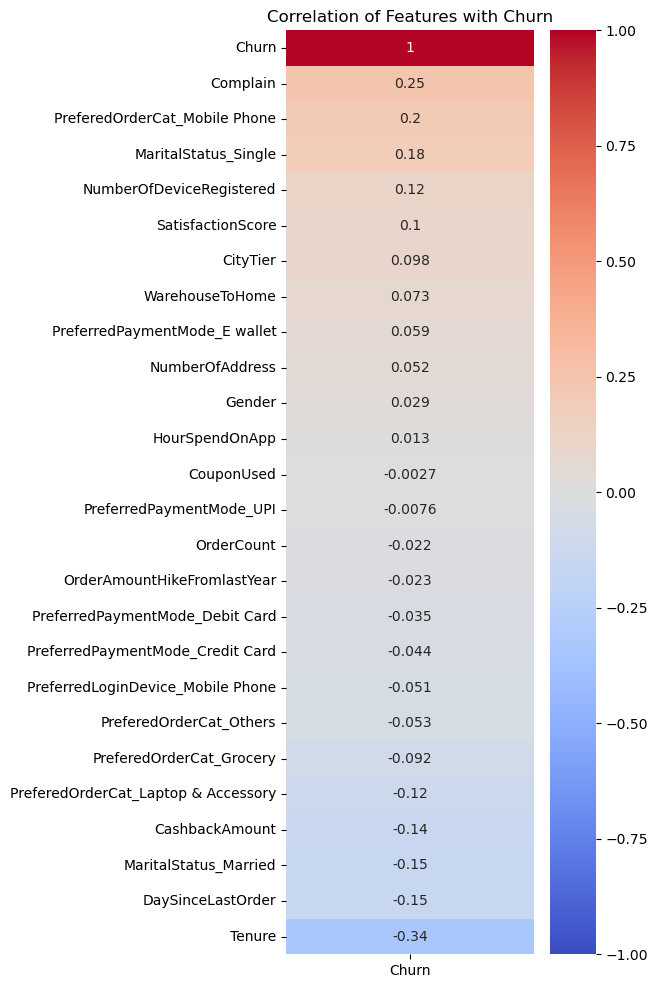

In [24]:
# Compute correlation matrix only for numeric columns
corr_matrix = df.corr(numeric_only=True)

# Focus on correlation with Churn
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()


Negative (lower value → less likely to churn):

- Tenure (-0.35) → Customers who have been on the platform longer are less likely to churn.
- DaySinceLastOrder (-0.16) → Customers who ordered more recently are less likely to churn.
- CashbackAmount (-0.15) → Customers receiving more cashback are less likely to churn.
- MaritalStatus_Married (-0.15) → Married customers churn less than single/divorced.

Positive (higher value → more likely to churn):

- Complain (+0.25) → Customers who raised a complaint are more likely to churn.
- PreferedOrderCat_Mobile Phone (+0.22) → Customers whose preferred category is Mobile Phone churn more.
- MaritalStatus_Single (+0.18) → Single customers churn more than married/divorced.

## Look for multicolinearity (VIF)

In [25]:
# Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [26]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                                feature        VIF
13                       CashbackAmount  52.310076
4                        HourSpendOnApp  24.154036
9           OrderAmountHikeFromlastYear  19.163406
5              NumberOfDeviceRegistered  16.480317
1                              CityTier   6.138007
11                           OrderCount   5.915334
6                     SatisfactionScore   5.628837
20  PreferedOrderCat_Laptop & Accessory   5.428816
16      PreferredPaymentMode_Debit Card   5.258950
21        PreferedOrderCat_Mobile Phone   5.258551
10                           CouponUsed   4.528003
2                       WarehouseToHome   4.258447
15     PreferredPaymentMode_Credit Card   4.150841
23                MaritalStatus_Married   4.139143
7                       NumberOfAddress   4.136157
12                    DaySinceLastOrder   3.965700
14    PreferredLoginDevice_Mobile Phone   3.435592
24                 MaritalStatus_Single   2.965376
0                              

- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

## Modeling Summary

The notebook stops short of formal model training. The final, reproducible model comparison now lives in `scripts/run_pipeline.py`, which applies the same cleaning and feature engineering every run, logs metrics to MLflow, and can write `artifacts/model_comparison.csv`.

Run from the project root:

```bash
python scripts/run_pipeline.py \
  --input "data/raw/E Commerce Dataset.xlsx" \
  --target Churn \
  --compare_models \
  --skip_validation
```


### Metric Priorities

Churn prediction has asymmetric costs. A false negative (FN) means the business misses a customer who actually churns; a false positive (FP) means the business may spend a retention offer on someone who would have stayed. The pipeline encodes this directly:

- **Model selection** is ranked by **PR-AUC** (average precision) — a threshold-free, prevalence-aware metric that is more informative than ROC-AUC at ~17% positives. ROC-AUC is still reported but de-prioritized (it is inflated by the large number of true negatives).
- **The decision threshold** is chosen to **minimize the FN/FP business cost** (`--threshold_metric cost`, default), where a missed churner costs `--fn_fp_ratio`x a false alarm (default 10:1). `f1`/`precision`/`recall` objectives are also available. The threshold is selected on out-of-fold CV predictions, never on the test set.
- **Probability calibration** (Brier score, ECE) is reported so the predicted probabilities can be trusted for risk ranking / expected-value targeting (or calibrated first if ECE is high).


In [27]:
from pathlib import Path
import pandas as pd

comparison_path = Path('../artifacts/model_comparison.csv')
if comparison_path.exists():
    model_comparison = pd.read_csv(comparison_path)
    # The pipeline ranks models by cross-validated PR-AUC (threshold-free,
    # prevalence-aware); precision/recall/f1 and test_cost are single-split
    # context at each model's out-of-fold-selected threshold.
    display(model_comparison.sort_values(['cv_pr_auc', 'cv_roc_auc'], ascending=False))
else:
    print('Run scripts/run_pipeline.py with --compare_models to generate artifacts/model_comparison.csv')


,model,cv_pr_auc,cv_pr_std,cv_roc_auc,cv_roc_std,threshold,precision,recall,f1,test_cost,cv_time
0,lightgbm,0.898140,0.021932,0.963410,0.010710,0.1712,0.757426,0.910714,0.827027,199.0,8.782257
1,xgboost,0.894392,0.019990,0.964632,0.009148,0.1089,0.686099,0.910714,0.782609,220.0,3.567799
2,random_forest,0.893489,0.024950,0.967302,0.008161,0.1475,0.554054,0.976190,0.706897,172.0,1.410220


### Interpretation Template

Use the pipeline output to discuss:

- Which model has the strongest **CV PR-AUC** — and whether the lead exceeds the CV std (otherwise the models are statistically tied).
- The **business cost** (`test_cost`) at each model's chosen threshold, and how it shifts with `--fn_fp_ratio`.
- The recall/precision trade-off the selected threshold implies (cost-based selection favors recall when FN >> FP).
- Whether the simpler baseline is close enough to the more complex model.
- Whether tuning changes the conclusion materially (often within noise on this dataset).
- Whether the probabilities are well calibrated (Brier/ECE) before using them as true probabilities.

This keeps the notebook focused on explaining the data and modeling decisions, while `run_pipeline.py` remains the source of truth for repeatable training and evaluation.
